# 02 Signal extraction

Notebook này chứa pipeline chính: đọc artifact preprocessing, trích xuất RGB theo ROI, chạy Green/CHROM/POS, tính HR/metrics, và ghi artifact signal. Module `airppg.signal_extraction.*` chỉ giữ helper nhỏ có thể tái sử dụng.

## 1. Config

In [1]:
from __future__ import annotations

import csv
from pathlib import Path
import sys
from typing import Any


def find_project_root(start: Path | None = None) -> Path:
    """Find repo root from either repository root or notebooks/ working directory."""
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "airppg").exists():
            return candidate
    raise RuntimeError(f"Cannot find project root from {current}")


PROJECT_ROOT = find_project_root()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from tqdm import tqdm

from airppg.metrics import align_ground_truth, evaluate_method
from airppg.paths import load_json, project_relpath, resolve_project_root, resolve_relative, to_builtin, write_json
from airppg.schemas import METHOD_NAMES, SIGNAL_EXTRACTION_SCHEMA_VERSION
from airppg.signal import estimate_hr_trace
from airppg.signal_extraction.baselines import run_baselines
from airppg.signal_extraction.config import SignalExtractionConfig
from airppg.signal_extraction.loaders import (
    load_ground_truth_npz,
    load_preprocessing_arrays,
    load_preprocessing_manifest,
    resolve_preprocessing_output_path,
    select_preprocessing_items,
)
from airppg.signal_extraction.rgb import extract_mean_rgb
from airppg.signal_extraction.visualization import build_visualization

PREPROCESSING_MANIFEST_PATH = Path("outputs/preprocessing/preprocessing_dataset_manifest.json")
SIGNAL_EXTRACTION_OUTPUT_ROOT = Path("outputs/signal_extraction")

PROCESS_ALL_PREPROCESSING_OUTPUTS = True
BATCH_LIMIT: int | None = None
MAX_FRAMES_PER_SAMPLE: int | None = None
WINDOW_SEC = 30.0
STEP_SEC = 1.0
HR_MIN_BPM = 42.0
HR_MAX_BPM = 210.0
SAVE_FIGURES = True
SHOW_SAMPLE_VISUALIZATION = True
PROGRESS = True

config = SignalExtractionConfig(
    preprocessing_manifest_path=PREPROCESSING_MANIFEST_PATH,
    signal_extraction_output_root=SIGNAL_EXTRACTION_OUTPUT_ROOT,
    process_all_preprocessing_outputs=PROCESS_ALL_PREPROCESSING_OUTPUTS,
    batch_limit=BATCH_LIMIT,
    max_frames_per_sample=MAX_FRAMES_PER_SAMPLE,
    window_sec=WINDOW_SEC,
    step_sec=STEP_SEC,
    hr_min_bpm=HR_MIN_BPM,
    hr_max_bpm=HR_MAX_BPM,
    save_figures=SAVE_FIGURES,
    show_sample_visualization=SHOW_SAMPLE_VISUALIZATION,
    progress=PROGRESS,
)

display(pd.DataFrame([config.to_manifest_config()]).T.rename(columns={0: "value"}))

,value
schema_version,signal_extraction_rppg_v1
preprocessing_manifest_path,outputs/preprocessing/preprocessing_dataset_ma...
signal_extraction_output_root,outputs/signal_extraction
process_all_preprocessing_outputs,True
batch_limit,None
max_frames_per_sample,None
window_sec,30.0
step_sec,1.0
hr_min_bpm,42.0
hr_max_bpm,210.0


## 2. Local output helpers

In [2]:
def output_relpath(path: Path, output_root: Path) -> str:
    try:
        return path.resolve().relative_to(output_root.resolve()).as_posix()
    except ValueError:
        return path.resolve().as_posix()


def write_metrics_csv(path: Path, metrics: dict[str, dict[str, float | int]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = ("method", "mae_bpm", "rmse_bpm", "pearson_r", "bias_bpm", "snr_db", "n_windows")
    with path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for method in METHOD_NAMES:
            writer.writerow({"method": method, **to_builtin(metrics[method])})


def write_summary_csv(path: Path, items: list[dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = ("sample_id", "split", "method", "mae_bpm", "rmse_bpm", "pearson_r", "bias_bpm", "snr_db", "n_windows")
    with path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for item in items:
            if item.get("status") != "processed":
                continue
            for method in METHOD_NAMES:
                writer.writerow({"sample_id": item["sample_id"], "split": item["split"], "method": method, **to_builtin(item["metrics"][method])})

## 3. Main signal extraction pipeline

In [3]:
PROJECT_ROOT = resolve_project_root(PROJECT_ROOT)
preprocessing_manifest_path = resolve_relative(config.preprocessing_manifest_path, PROJECT_ROOT)
output_root = resolve_relative(config.signal_extraction_output_root, PROJECT_ROOT)
output_root.mkdir(parents=True, exist_ok=True)
preprocessing_manifest = load_preprocessing_manifest(preprocessing_manifest_path)
selected_items = select_preprocessing_items(preprocessing_manifest, config.process_all_preprocessing_outputs, config.batch_limit)

manifest_items: list[dict[str, Any]] = []
iterator = tqdm(selected_items, desc="Signal extraction samples", unit="sample") if config.progress else selected_items
for entry in iterator:
    try:
        split = str(entry["split"])
        sample_id = str(entry["sample_id"])
        output_dir = output_root / split / sample_id
        output_dir.mkdir(parents=True, exist_ok=True)

        arrays = load_preprocessing_arrays(resolve_preprocessing_output_path(entry["roi_npz"], preprocessing_manifest_path))
        preprocessing_metadata = load_json(resolve_preprocessing_output_path(entry["metadata_json"], preprocessing_manifest_path))
        gt = load_ground_truth_npz(resolve_preprocessing_output_path(entry["ground_truth_npz"], preprocessing_manifest_path))
        video_path = resolve_relative(entry["video_relpath"], PROJECT_ROOT)
        fps = float(preprocessing_metadata["video"]["fps"])

        rgb_result = extract_mean_rgb(video_path, arrays, preprocessing_metadata, max_frames=config.max_frames_per_sample, progress=False)
        baselines = run_baselines(rgb_result["mean_rgb"], fps, config.hr_min_bpm, config.hr_max_bpm)

        hr_results: dict[str, np.ndarray] = {}
        hr_timestamps = None
        for method in METHOD_NAMES:
            method_hr, method_ts = estimate_hr_trace(
                baselines[method]["signal"],
                rgb_result["timestamps"],
                fps,
                config.window_sec,
                config.step_sec,
                config.hr_min_bpm,
                config.hr_max_bpm,
            )
            hr_results[method] = method_hr
            if hr_timestamps is None:
                hr_timestamps = method_ts
        if hr_timestamps is None:
            hr_timestamps = np.array([], dtype=np.float32)

        metrics = {
            method: evaluate_method(hr_results[method], hr_timestamps, gt, baselines[method]["signal"], fps, config.hr_min_bpm, config.hr_max_bpm)
            for method in METHOD_NAMES
        }

        figure_path = output_dir / "visualization.png" if config.save_figures else None
        fig = build_visualization(
            sample_id,
            rgb_result,
            baselines,
            hr_results,
            hr_timestamps,
            gt,
            metrics,
            fps,
            config.hr_min_bpm,
            config.hr_max_bpm,
            output_path=figure_path,
        )
        plt.close(fig)

        rppg_signals = np.stack([baselines[method]["signal"] for method in METHOD_NAMES], axis=1).astype(np.float32)
        rppg_roi_signals = np.stack([baselines[method]["per_roi"] for method in METHOD_NAMES], axis=0).astype(np.float32)
        hr_estimates = np.stack([hr_results[method] for method in METHOD_NAMES], axis=1).astype(np.float32)
        gt_aligned = align_ground_truth(gt, hr_timestamps).astype(np.float32)

        signals_path = output_dir / "signals.npz"
        np.savez_compressed(
            signals_path,
            schema_version=np.array(SIGNAL_EXTRACTION_SCHEMA_VERSION),
            sample_id=np.array(sample_id),
            split=np.array(split),
            frame_indices=rgb_result["frame_indices"].astype(np.int64),
            timestamps=rgb_result["timestamps"].astype(np.float32),
            valid=rgb_result["valid"].astype(bool),
            roi_names=rgb_result["roi_names"].astype(str),
            method_names=np.array(METHOD_NAMES),
            mean_rgb=rgb_result["mean_rgb"].astype(np.float32),
            rppg_signals=rppg_signals,
            rppg_roi_signals=rppg_roi_signals,
            hr_timestamps=hr_timestamps.astype(np.float32),
            hr_estimates=hr_estimates,
            gt_timestamps=gt["timestamps"].astype(np.float32),
            gt_heart_rate_bpm=gt["heart_rate_bpm"].astype(np.float32),
            gt_aligned_to_hr=gt_aligned,
            ppg_timestamps=gt["ppg_timestamps"].astype(np.float32),
            ppg_signal=gt["ppg_signal"].astype(np.float32),
            spo2_percent=gt["spo2_percent"].astype(np.float32),
        )

        config_payload = config.to_manifest_config()
        config_payload["preprocessing_manifest_path"] = project_relpath(preprocessing_manifest_path, PROJECT_ROOT)
        config_payload["signal_extraction_output_root"] = project_relpath(output_root, PROJECT_ROOT)
        metadata_payload = {
            "schema_version": SIGNAL_EXTRACTION_SCHEMA_VERSION,
            "sample_id": sample_id,
            "split": split,
            "source_preprocessing_schema_version": preprocessing_metadata.get("schema_version"),
            "inputs": {
                "preprocessing_manifest": project_relpath(preprocessing_manifest_path, PROJECT_ROOT),
                "roi_npz": entry["roi_npz"],
                "metadata_json": entry["metadata_json"],
                "ground_truth_npz": entry["ground_truth_npz"],
                "video_relpath": entry["video_relpath"],
            },
            "config": config_payload,
            "roi_names": rgb_result["roi_names"].tolist(),
            "method_names": list(METHOD_NAMES),
            "frame_count": int(len(rgb_result["frame_indices"])),
            "valid_frame_count": int(np.sum(rgb_result["valid"])),
            "hr_window_count": int(len(hr_timestamps)),
            "metrics": metrics,
        }
        write_json(output_dir / "metrics.json", {"schema_version": SIGNAL_EXTRACTION_SCHEMA_VERSION, "sample_id": sample_id, "metrics": metrics})
        write_metrics_csv(output_dir / "metrics.csv", metrics)
        write_json(output_dir / "metadata.json", metadata_payload)

        manifest_items.append({
            "sample_id": sample_id,
            "split": split,
            "status": "processed",
            "outputs": {
                "signals_npz": output_relpath(signals_path, output_root),
                "metrics_json": output_relpath(output_dir / "metrics.json", output_root),
                "metrics_csv": output_relpath(output_dir / "metrics.csv", output_root),
                "metadata_json": output_relpath(output_dir / "metadata.json", output_root),
                "visualization_png": output_relpath(output_dir / "visualization.png", output_root),
            },
            "frame_count": int(len(rgb_result["frame_indices"])),
            "valid_frame_count": int(np.sum(rgb_result["valid"])),
            "hr_window_count": int(len(hr_timestamps)),
            "metrics": metrics,
        })
    except Exception as exc:
        manifest_items.append({"sample_id": entry.get("sample_id"), "split": entry.get("split"), "status": "failed", "error": str(exc)})

processed_count = sum(item.get("status") == "processed" for item in manifest_items)
failed_count = sum(item.get("status") == "failed" for item in manifest_items)
config_payload = config.to_manifest_config()
config_payload["preprocessing_manifest_path"] = project_relpath(preprocessing_manifest_path, PROJECT_ROOT)
config_payload["signal_extraction_output_root"] = project_relpath(output_root, PROJECT_ROOT)
manifest = {
    "schema_version": SIGNAL_EXTRACTION_SCHEMA_VERSION,
    "preprocessing_manifest": project_relpath(preprocessing_manifest_path, PROJECT_ROOT),
    "output_root_hint": project_relpath(output_root, PROJECT_ROOT),
    "config": config_payload,
    "counts": {"total": len(manifest_items), "processed": processed_count, "failed": failed_count},
    "items": manifest_items,
}
write_json(output_root / "signal_extraction_dataset_manifest.json", manifest)
write_summary_csv(output_root / "signal_extraction_metrics_summary.csv", manifest_items)

display(pd.DataFrame([manifest["counts"]]))
summary_rows = []
for item in manifest_items:
    if item.get("status") != "processed":
        continue
    for method, metric_values in item["metrics"].items():
        summary_rows.append({"sample_id": item["sample_id"], "split": item["split"], "method": method, **metric_values})
display(pd.DataFrame(summary_rows))
if failed_count:
    display(pd.DataFrame([item for item in manifest_items if item.get("status") == "failed"]))
    raise RuntimeError(f"Signal extraction failed for {failed_count} sample(s).")

Signal extraction samples: 100%|██████████| 49/49 [10:09<00:00, 12.43s/sample]


,total,processed,failed
0,49,49,0


,sample_id,split,method,mae_bpm,rmse_bpm,pearson_r,bias_bpm,snr_db,n_windows
0,ubfc_d1_10-gt_vid_3440368f,train,green,3.070277,3.874517,-0.480308,-2.602805,1.471948,13
1,ubfc_d1_10-gt_vid_3440368f,train,chrom,18.605658,18.907287,-0.570277,-18.605658,-8.732737,13
2,ubfc_d1_10-gt_vid_3440368f,train,pos,3.070277,3.874517,-0.480308,-2.602805,6.198694,13
3,ubfc_d1_11-gt_vid_97458e9b,train,green,1.300661,1.517053,0.722826,-0.811716,-3.861708,50
4,ubfc_d1_11-gt_vid_97458e9b,train,chrom,32.097305,32.306275,-0.316717,-32.097305,-8.820704,50
...,...,...,...,...,...,...,...,...,...
142,ubfc_d2_subject8_vid_cf94b659,train,chrom,61.918750,62.165742,-0.266810,-61.918750,-12.861102,38
143,ubfc_d2_subject8_vid_cf94b659,train,pos,1.969961,2.318584,0.450012,-0.363609,5.514346,38
144,ubfc_d2_subject9_vid_7f8f2cc8,train,green,18.682134,30.473681,-0.418189,-16.255912,-7.264868,38
145,ubfc_d2_subject9_vid_7f8f2cc8,train,chrom,66.845706,67.232389,-0.507292,-66.845706,-16.058261,38


## 4. Visualization sample

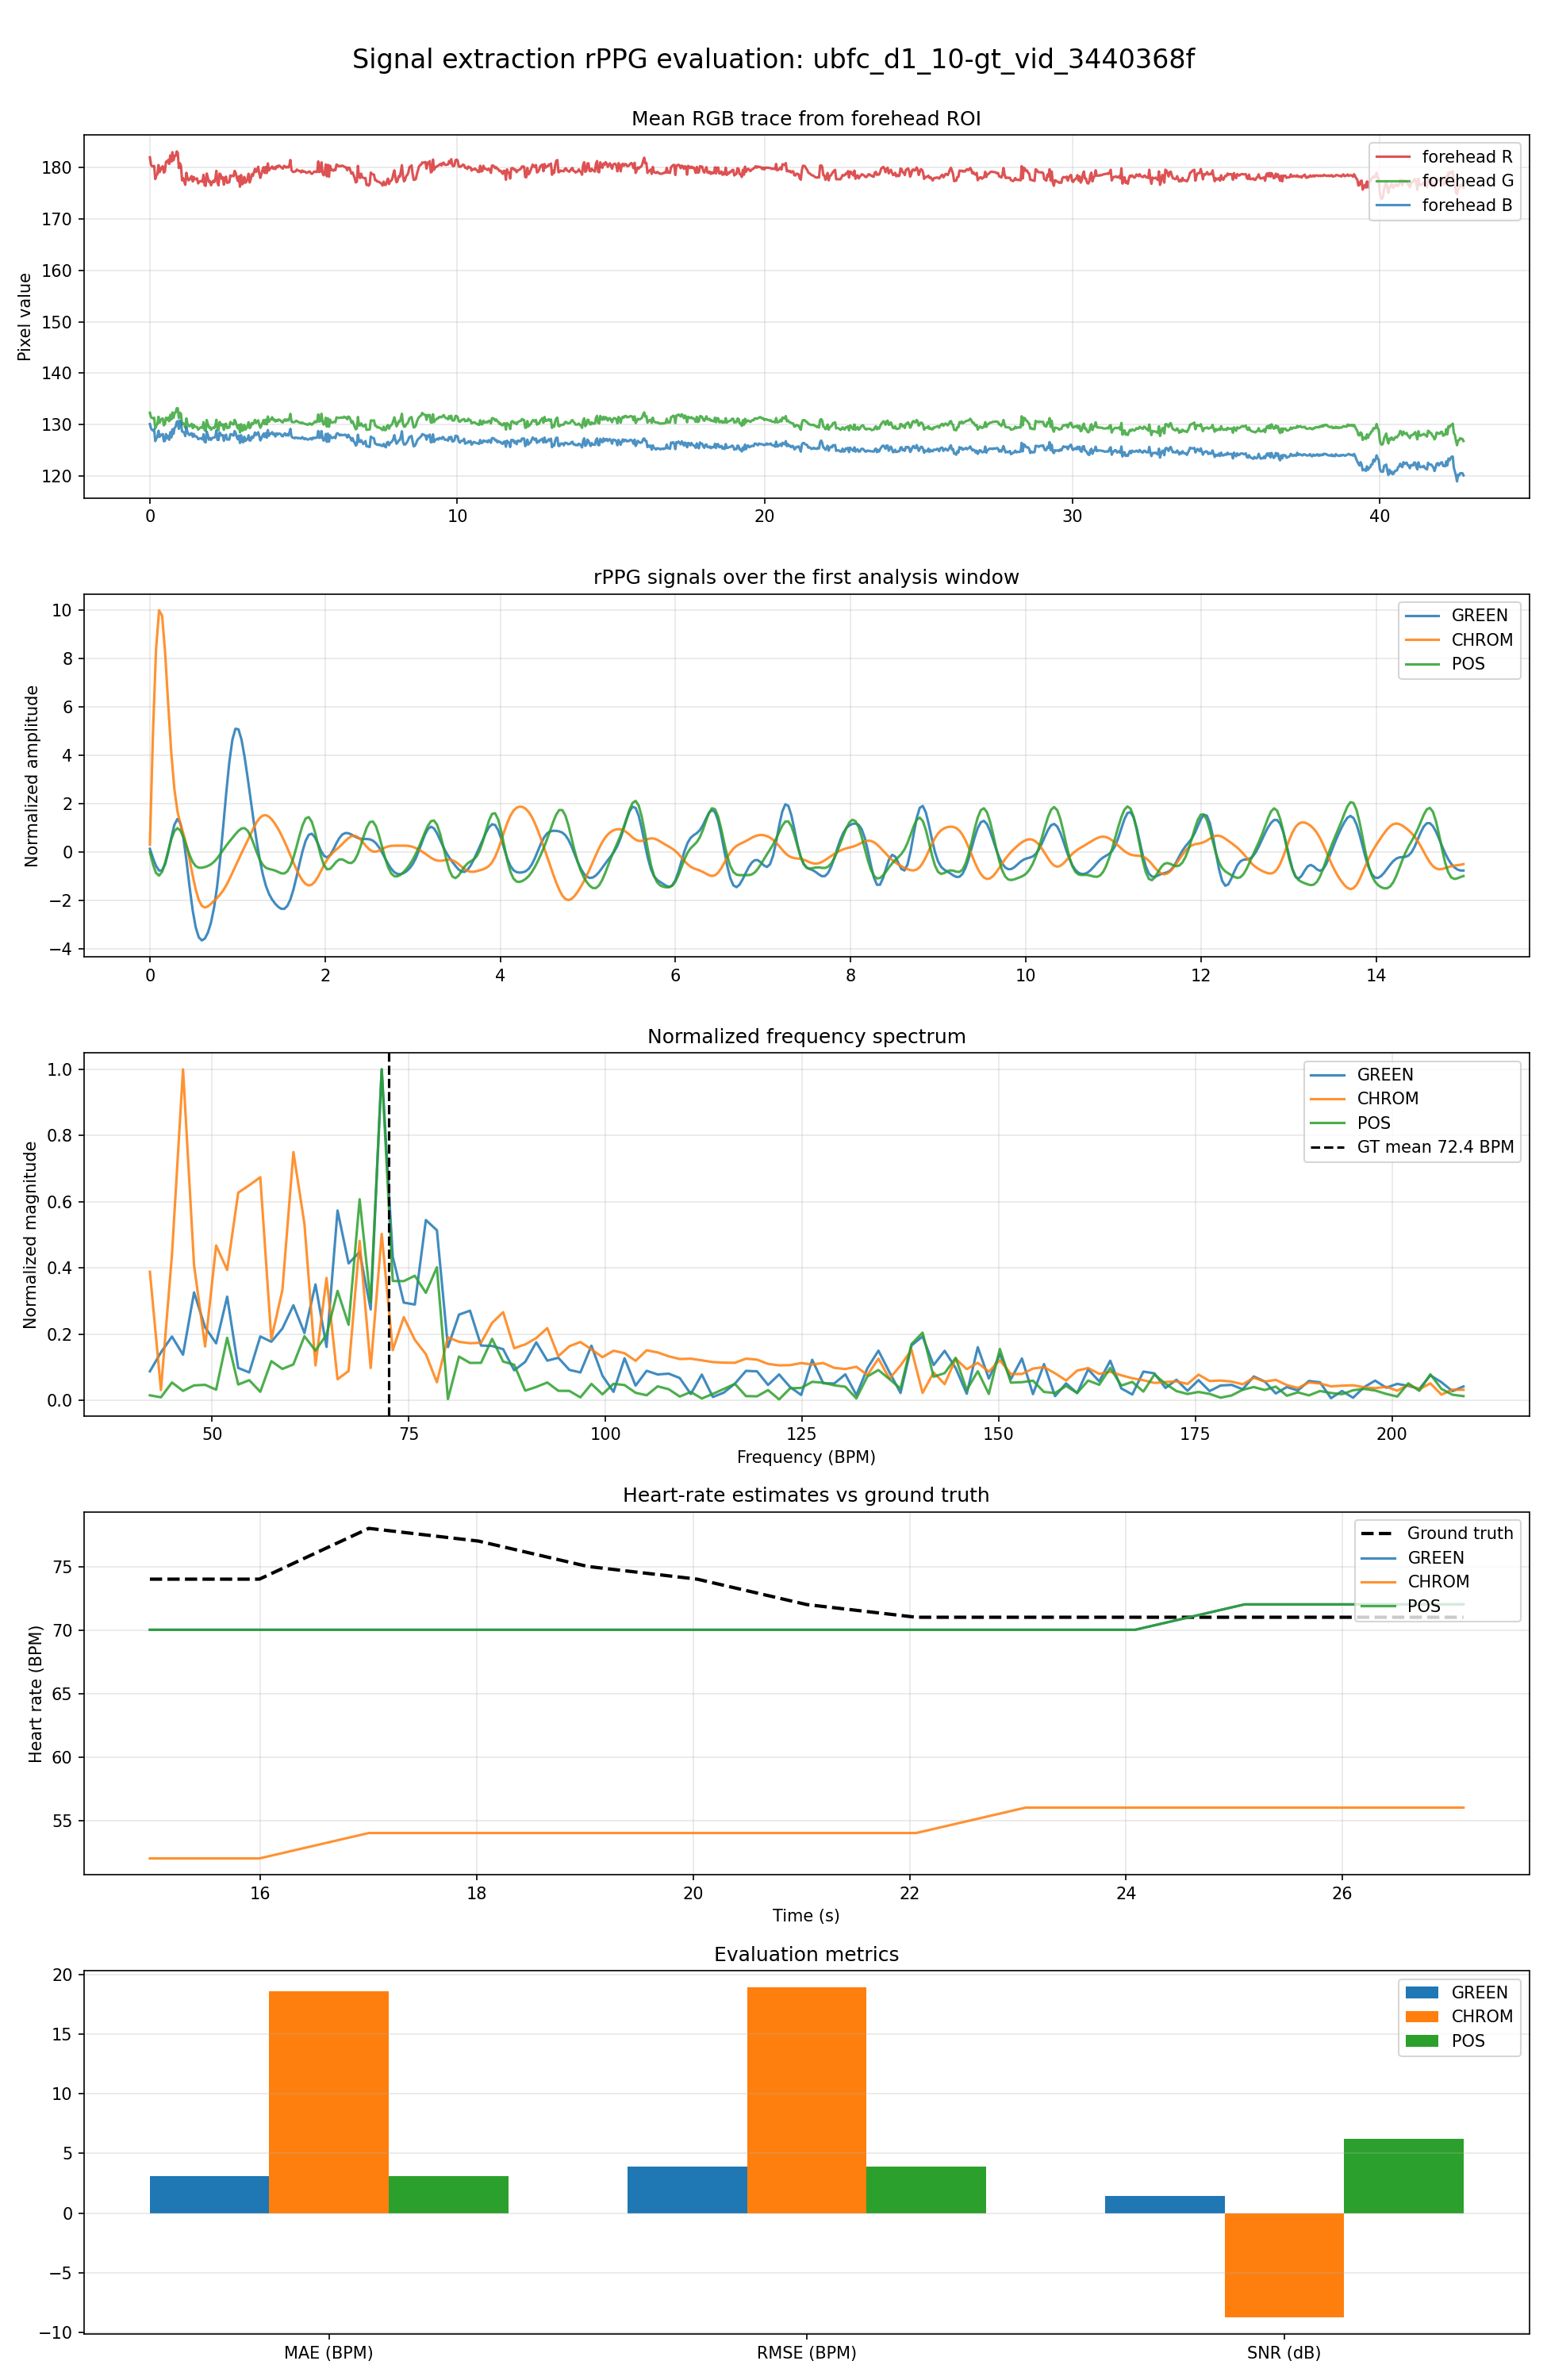

In [4]:
if SHOW_SAMPLE_VISUALIZATION:
    first_processed = next((item for item in manifest.get("items", []) if item.get("status") == "processed"), None)
    if first_processed is not None:
        visualization_path = output_root / first_processed["outputs"]["visualization_png"]
        if visualization_path.exists():
            display(Image(filename=str(visualization_path)))